In [8]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [9]:
df = pd.read_csv("../data/processed/preprocessed_data.csv")
df.head()

,Number of followers,Number of following,tfidf_similarity,Number of Activity,Number of Issue,Number of Pull Request,Number of Repository,Number of Commit,Number of Active day,Periodicity of Activities,Number of Connection Account,Median Response Time,label,issue_activity_ratio,pr_activity_ratio,commit_per_repo,follower_following_ratio,activity_per_day
0,1.609438,0.693147,0.019511,10.808246,4.454347,4.043051,4.442651,10.297684,246,0.967936,1.609438,10.100715,0,0.377223,0.342392,1.892034,0.950560,0.043758
1,2.197225,1.945910,0.000000,10.128070,3.091042,2.484907,1.609438,10.126631,339,0.962913,1.386294,7.357237,0,0.277770,0.223301,3.880771,0.745856,0.029788
2,7.089243,5.379897,0.000000,9.421573,3.951244,1.609438,5.111988,9.403602,358,0.961636,1.386294,9.943034,0,0.379141,0.154433,1.538551,1.111185,0.026244
3,4.356709,1.098612,0.002806,10.808246,5.497168,8.795955,6.278521,10.297684,235,0.957628,5.303305,7.662259,1,0.465536,0.744899,1.414804,2.075995,0.045798
4,1.386294,1.098612,0.019992,8.472196,4.828314,0.000000,4.382027,8.428143,148,0.956401,0.693147,9.477342,0,0.509735,0.000000,1.565979,0.660577,0.056860


In [13]:
X = df.drop("label", axis=1)
y = df["label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
with open("../app/models/model.pkl", "rb") as f:
    model = pickle.load(f)

In [12]:
y_pred = model.predict(X_test)

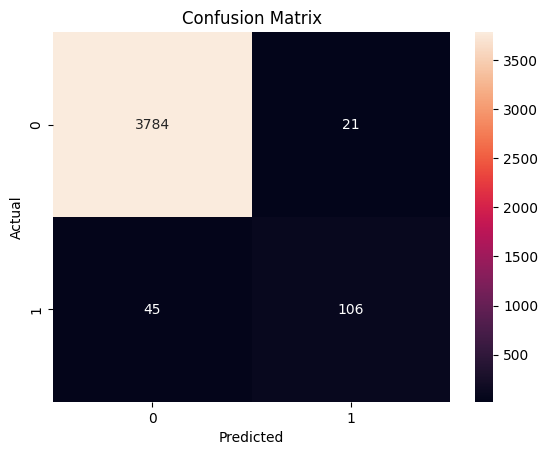

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3805
           1       0.83      0.70      0.76       151

    accuracy                           0.98      3956
   macro avg       0.91      0.85      0.88      3956
weighted avg       0.98      0.98      0.98      3956



In [16]:
importance = model.feature_importances_
features = X.columns

import pandas as pd

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feat_df.head(10)

,Feature,Importance
2,tfidf_similarity,0.236190
1,Number of following,0.155520
4,Number of Issue,0.069225
0,Number of followers,0.061009
13,pr_activity_ratio,0.059926
3,Number of Activity,0.055688
6,Number of Repository,0.049310
5,Number of Pull Request,0.043261
12,issue_activity_ratio,0.041894
14,commit_per_repo,0.037823


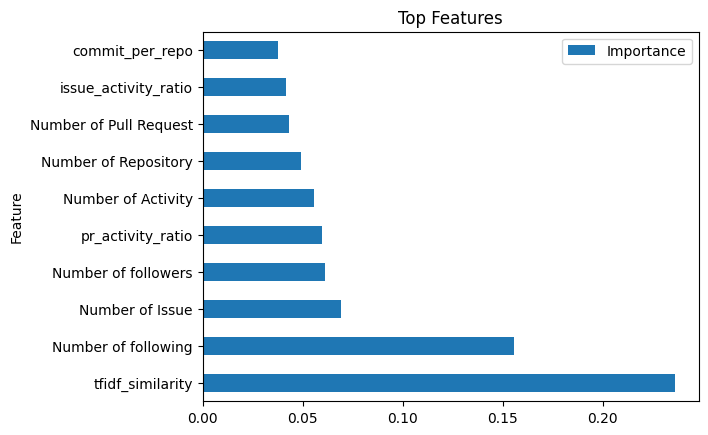

In [17]:
feat_df.head(10).plot(kind='barh', x='Feature', y='Importance')

plt.title("Top Features")
plt.savefig("feature_importance.png")
plt.show()